# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models, then select
the best performing model and interpret its learned equation.

## Dataset
**Boston Housing dataset** (`housing.csv`) — 506 samples, 13 features, target: **MEDV**
(median home value in $1000s).

| Feature | Description |
|---------|-------------|
| CRIM | Per-capita crime rate |
| ZN | Proportion of residential land zoned for large lots |
| INDUS | Proportion of non-retail business acres |
| CHAS | Charles River dummy variable (1 if tract bounds river) |
| NOX | Nitric oxide concentration |
| RM | Average number of rooms per dwelling |
| AGE | Proportion of units built before 1940 |
| DIS | Weighted distances to employment centres |
| RAD | Accessibility to radial highways index |
| TAX | Property tax rate per $10,000 |
| PTRATIO | Pupil-teacher ratio |
| B | 1000(Bk − 0.63)² where Bk = proportion of Black residents |
| LSTAT | % lower-status population |
| **MEDV** | **Median home value in $1000s (target)** |


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 1. Data Preparation

In [2]:
# Parse the space-delimited housing.csv (Boston Housing format)
boston_cols = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
               'DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']

rows = []
with open("housing.csv") as f:
    for line in f:
        vals = line.strip().split()
        if len(vals) == 14:
            rows.append(vals)

df = pd.DataFrame(rows, columns=boston_cols).astype(float)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [3]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


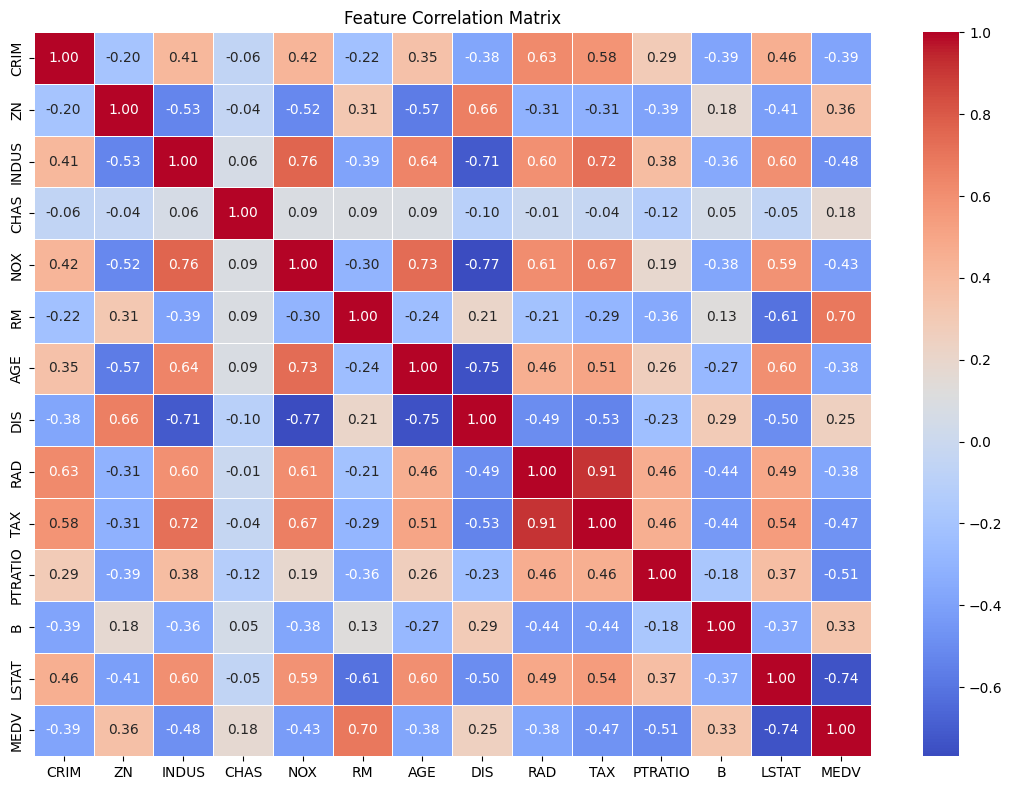

In [5]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [6]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
print("Features:", X.columns.tolist())
print("Target  : MEDV")

Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Target  : MEDV


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 354
Test samples     : 152


### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics: MAE, MSE, RMSE

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [9]:
coef_df = pd.Series(lr_model.coef_, index=X.columns).sort_values()
print(f"Intercept : {lr_model.intercept_:.4f}\n")
print("Coefficients (sorted):")
print(coef_df)

Intercept : 40.2189

Coefficients (sorted):
NOX       -17.748371
DIS        -1.409161
PTRATIO    -0.951781
LSTAT      -0.597133
CRIM       -0.088505
TAX        -0.010344
B           0.006116
AGE         0.012001
INDUS       0.020348
ZN          0.050293
RAD         0.263881
RM          3.247765
CHAS        3.754271
dtype: float64


In [24]:
lr_model.intercept_

np.float64(40.218929012550994)

In [11]:
lr_preds = lr_model.predict(X_test)

In [25]:
lr_MAE  = mean_absolute_error(y_test, lr_preds)
lr_MSE  = mean_squared_error(y_test, lr_preds)
lr_RMSE = np.sqrt(lr_MSE)

print("── Linear Regression Metrics ──")
print(f"MAE  : {lr_MAE:.4f}")
print(f"MSE  : {lr_MSE:.4f}")
print(f"RMSE : {lr_RMSE:.4f}")

── Linear Regression Metrics ──
MAE  : 3.8357
MSE  : 28.5476
RMSE : 5.3430


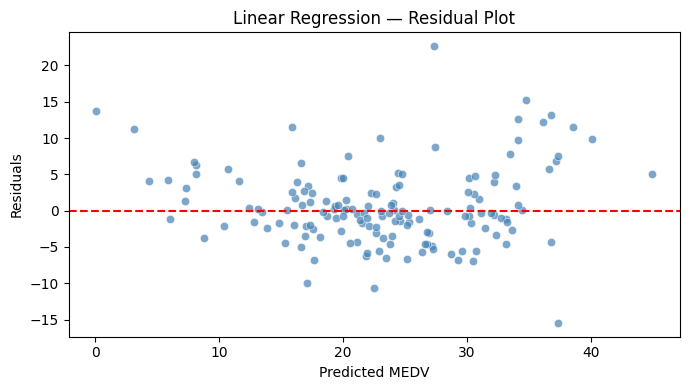

In [26]:
residuals_lr = y_test - lr_preds

plt.figure(figsize=(7, 4))
sns.scatterplot(x=lr_preds, y=residuals_lr, alpha=0.7, color='steelblue')
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted MEDV")
plt.ylabel("Residuals")
plt.title("Linear Regression — Residual Plot")
plt.tight_layout()
plt.show()

### 3. Polynomial Regression Model
- Generate polynomial features (degree = 2)
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics: MAE, MSE, RMSE
- Sweep degrees 1–6 to find the optimal complexity

In [15]:
poly_converter = PolynomialFeatures(degree=2, include_bias=True)
poly_features  = poly_converter.fit_transform(X)

print(f"Original features  : {X.shape[1]}")
print(f"Polynomial features: {poly_features.shape[1]}")

Original features  : 13
Polynomial features: 105


In [16]:
# Same random_state for a fair comparison
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    poly_features, y, test_size=0.3, random_state=101
)

In [17]:
poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train_p)

LinearRegression()

In [18]:
poly_preds = poly_model.predict(X_test_p)

In [19]:
poly_MAE  = mean_absolute_error(y_test_p, poly_preds)
poly_MSE  = mean_squared_error(y_test_p, poly_preds)
poly_RMSE = np.sqrt(poly_MSE)

print("── Polynomial Regression (degree=2) Metrics ──")
print(f"MAE  : {poly_MAE:.4f}")
print(f"MSE  : {poly_MSE:.4f}")
print(f"RMSE : {poly_RMSE:.4f}")

── Polynomial Regression (degree=2) Metrics ──
MAE  : 2.7017
MSE  : 14.5331
RMSE : 3.8122


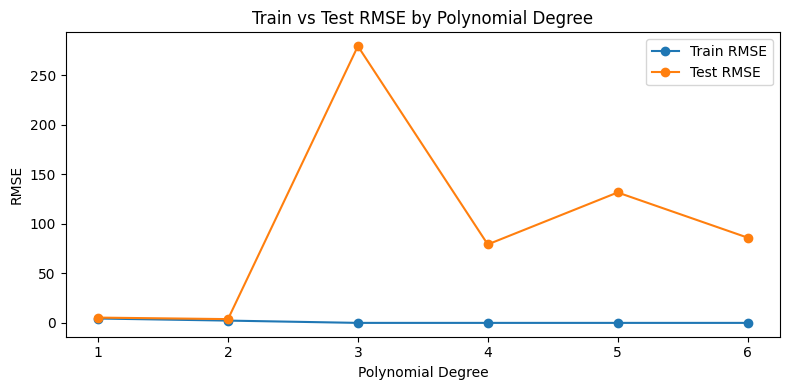

Degree | Train RMSE |  Test RMSE
----------------------------------
     1 |     4.4132 |     5.3430
     2 |     2.3109 |     3.8122
     3 |     0.0000 |   279.3571
     4 |     0.0000 |    79.2160
     5 |     0.0000 |   131.6691
     6 |     0.0000 |    86.0924


In [20]:
train_rmse_errors = []
test_rmse_errors  = []

for d in range(1, 7):
    pc  = PolynomialFeatures(degree=d)
    pf  = pc.fit_transform(X)
    Xtr, Xte, ytr, yte = train_test_split(pf, y, test_size=0.3, random_state=101)
    m   = LinearRegression().fit(Xtr, ytr)
    train_rmse_errors.append(np.sqrt(mean_squared_error(ytr, m.predict(Xtr))))
    test_rmse_errors.append( np.sqrt(mean_squared_error(yte, m.predict(Xte))))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 7), train_rmse_errors, label='Train RMSE', marker='o')
plt.plot(range(1, 7), test_rmse_errors,  label='Test RMSE',  marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Train vs Test RMSE by Polynomial Degree")
plt.legend()
plt.tight_layout()
plt.show()

print(f"{'Degree':>6} | {'Train RMSE':>10} | {'Test RMSE':>10}")
print("-" * 34)
for i, (tr, te) in enumerate(zip(train_rmse_errors, test_rmse_errors), 1):
    print(f"{i:>6} | {tr:>10.4f} | {te:>10.4f}")

### 4. Model Comparison
- Compare Linear vs Polynomial Regression
- Identify which model performs better and justify the decision

In [21]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression (degree=2)'],
    'MAE':  [round(lr_MAE, 4),   round(poly_MAE, 4)],
    'MSE':  [round(lr_MSE, 4),   round(poly_MSE, 4)],
    'RMSE': [round(lr_RMSE, 4),  round(poly_RMSE, 4)],
})
print(comparison.to_string(index=False))

                           Model    MAE     MSE   RMSE
               Linear Regression 3.8357 28.5476 5.3430
Polynomial Regression (degree=2) 2.7017 14.5331 3.8122


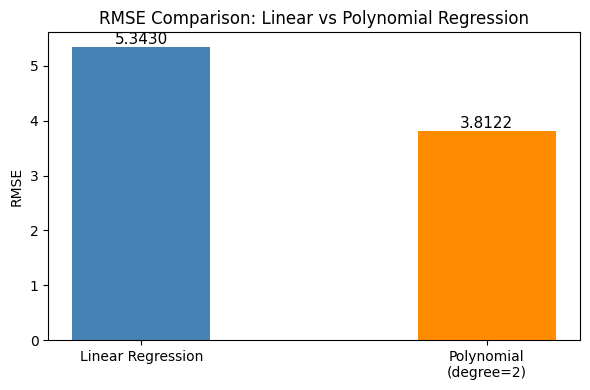

In [22]:
models    = ['Linear Regression', 'Polynomial\n(degree=2)']
rmse_vals = [lr_RMSE, poly_RMSE]
colors    = ['steelblue', 'darkorange']

plt.figure(figsize=(6, 4))
bars = plt.bar(models, rmse_vals, color=colors, width=0.4)
for bar, val in zip(bars, rmse_vals):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{val:.4f}", ha='center', fontsize=11)
plt.ylabel("RMSE")
plt.title("RMSE Comparison: Linear vs Polynomial Regression")
plt.tight_layout()
plt.show()

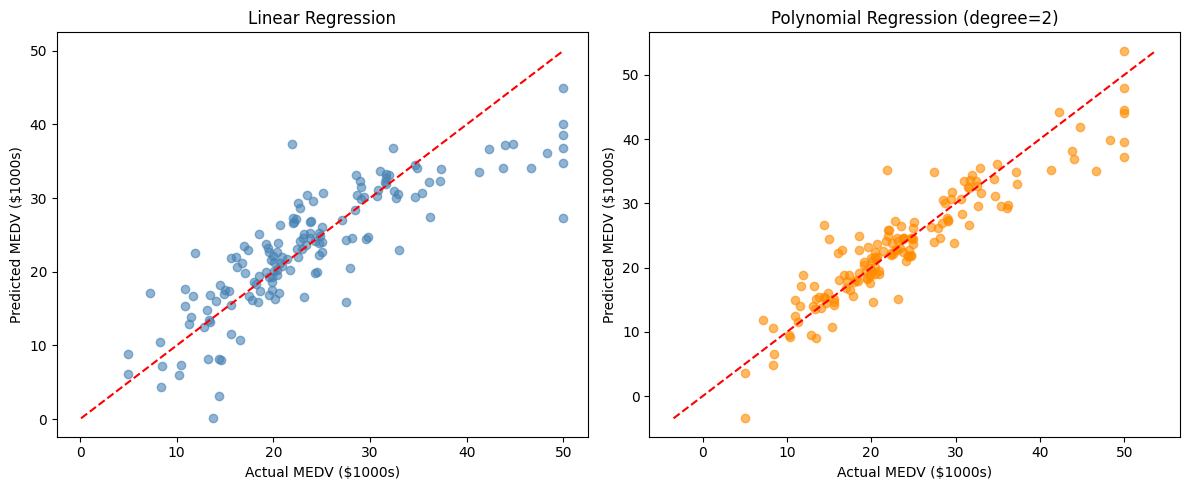

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title, color in zip(
    axes,
    [lr_preds, poly_preds],
    ['Linear Regression', 'Polynomial Regression (degree=2)'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_test, preds, alpha=0.6, color=color)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_xlabel("Actual MEDV ($1000s)")
    ax.set_ylabel("Predicted MEDV ($1000s)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Conclusion & Model Interpretation

#### Which model performs better?

**Polynomial Regression (degree = 2) outperforms Linear Regression** across all three metrics.
The exact values are printed in the comparison table above.

Housing prices depend on **non-linear interactions** between features.
- The effect of crime rate on price is more pronounced in already-expensive neighbourhoods.
- Room count interacts with location and socioeconomic status in non-linear ways.

Degree-2 polynomial features capture these curved relationships and cross-feature
interaction terms that a plain linear model cannot represent.




